# Tensor Flow Implementation

To implement the following neural network:

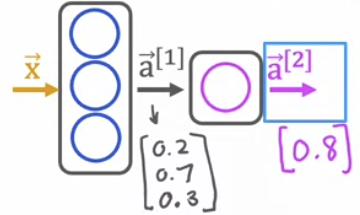

```
x = np.array([ [200.0, 17.0] ])  # 2d array, NOT 1d array.
layer_1 = Dense(units=3, activation="sigmoid")
a_1 = layer_1(x)    # An array with 3 activations/outputs.

layer_2 = Dense(units = 1, activation="sigmoid")
a2 = layer_2(a1)    # An array with a single activation/output.

yhat = None
if a2 >= 0.5:
    yhat = 1
else:
    yhat = 0
```

## Sequential object

Instead of manually passing activations from layer to layer, the `sequential` object can be used.

```
model = Sequential([ layer1, layer2 ])
```

## Training

This is done with two function calls.

```
model.compile(...)  # More on this on week 2
model.fit(x, y)
```

## Prediction

```
model.predict(x_new)
```

<br><br>

# Tensor Flow Lab

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./lib/deeplearning.mplstyle')
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from lib.lab_utils_common import dlc
from lib.lab_coffee_utils import load_coffee_data, plt_roast, plt_prob, plt_layer, plt_network, plt_output_unit
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

2024-10-06 13:08:01.615147: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-06 13:08:01.623230: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-06 13:08:01.632261: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-06 13:08:01.634905: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-06 13:08:01.642177: I tensorflow/core/platform/cpu_feature_guar

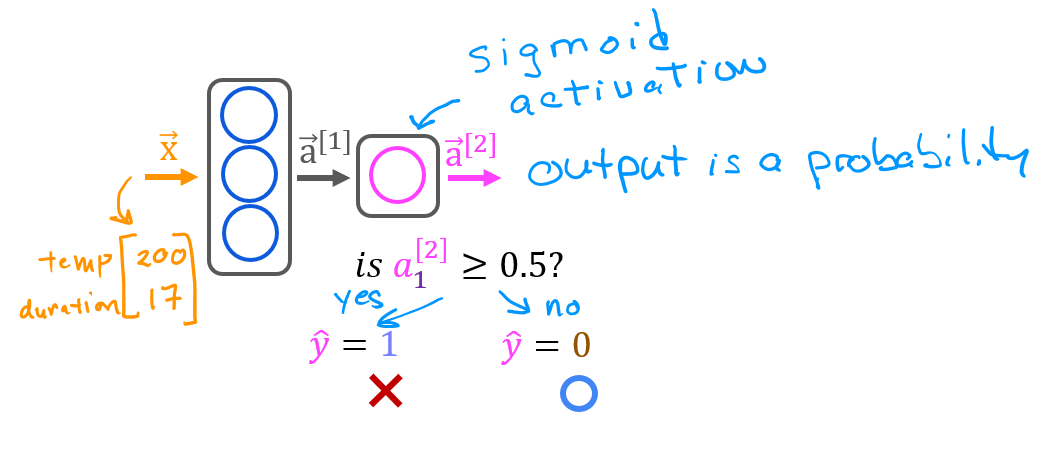

In [2]:
# DATASET
# X is a 2d matrix with two columns and 200 rows or entries.

X,Y = load_coffee_data();
print(X.shape, Y.shape)

(200, 2) (200, 1)


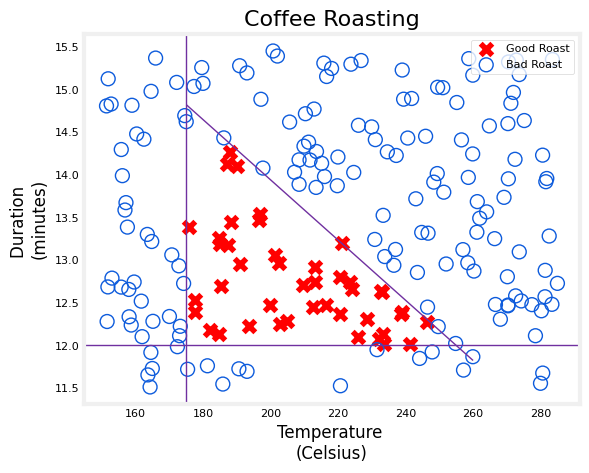

In [3]:
plt_roast(X,Y)

In [4]:
# NORMALIZE THE DATA

print(f"Temperature Max, Min pre normalization: {np.max(X[:,0]):0.2f}, {np.min(X[:,0]):0.2f}")
print(f"Duration    Max, Min pre normalization: {np.max(X[:,1]):0.2f}, {np.min(X[:,1]):0.2f}")
norm_l = tf.keras.layers.Normalization(axis=-1)
norm_l.adapt(X)  # learns mean, variance
Xn = norm_l(X)
print(f"Temperature Max, Min post normalization: {np.max(Xn[:,0]):0.2f}, {np.min(Xn[:,0]):0.2f}")
print(f"Duration    Max, Min post normalization: {np.max(Xn[:,1]):0.2f}, {np.min(Xn[:,1]):0.2f}")

Temperature Max, Min pre normalization: 284.99, 151.32
Duration    Max, Min pre normalization: 15.45, 11.51
Temperature Max, Min post normalization: 1.66, -1.69
Duration    Max, Min post normalization: 1.79, -1.70


2024-10-06 13:08:02.486709: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2024-10-06 13:08:02.486724: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:135] retrieving CUDA diagnostic information for host: jose-miralles-MS-7D25
2024-10-06 13:08:02.486727: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:142] hostname: jose-miralles-MS-7D25
2024-10-06 13:08:02.486768: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:166] libcuda reported version is: 550.107.2
2024-10-06 13:08:02.486775: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:170] kernel reported version is: 550.107.2
2024-10-06 13:08:02.486777: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:249] kernel version seems to match DSO: 550.107.2


In [5]:
# Tile/copy data to increase training set size and reduce training epochs.
Xt = np.tile(Xn,(1000,1))
Yt= np.tile(Y,(1000,1))   
print(Xt.shape, Yt.shape)   

(200000, 2) (200000, 1)


In [6]:
#  Create model

tf.random.set_seed(1234)  # applied to achieve consistent results
model = Sequential(
    [
        tf.keras.Input(shape=(2,)), # Passing a shape is optional. But it makes it easier to explore TF models.
        Dense(3, activation='sigmoid', name = 'layer1'),
        Dense(1, activation='sigmoid', name = 'layer2')
     ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
# The parameter counts in the summary correspond to the number of elemetns in the weight and bias arrays.

L1_num_params = 2 * 3 + 3   # W1 parameters  + b1 parameters
L2_num_params = 3 * 1 + 1   # W2 parameters  + b2 parameters
print("L1 params = ", L1_num_params, ", L2 params = ", L2_num_params  )

L1 params =  9 , L2 params =  4


In [8]:
# Print weights and biases

W1, b1 = model.get_layer("layer1").get_weights()
W2, b2 = model.get_layer("layer2").get_weights()
print(f"W1{W1.shape}:\n", W1, f"\nb1{b1.shape}:", b1)
print(f"W2{W2.shape}:\n", W2, f"\nb2{b2.shape}:", b2)

W1(2, 3):
 [[ 0.12 -0.32  0.07]
 [ 0.2  -0.29 -0.3 ]] 
b1(3,): [0. 0. 0.]
W2(3, 1):
 [[-0.73]
 [ 0.22]
 [ 0.47]] 
b2(1,): [0.]


In [9]:
# Fit and compile

model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
)

model.fit(
    Xt,Yt,            
    epochs=20, # Number of runs during training
)

Epoch 1/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 224us/step - loss: 0.3139
Epoch 2/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1s 222us/step - loss: 0.1370
Epoch 3/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1s 226us/step - loss: 0.1264
Epoch 4/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1s 227us/step - loss: 0.1165
Epoch 5/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1s 226us/step - loss: 0.0845
Epoch 6/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1s 229us/step - loss: 0.0194
Epoch 7/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1s 228us/step - loss: 0.0121
Epoch 8/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1s 228us/step - loss: 0.0084
Epoch 9/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1s 234us/step - loss: 0.0060
Epoch 10/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1s 222us/step - loss: 0.0043
Epoch 11/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1s 226us/step - loss: 0.0031
Epoch 12/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1s 230us/step - loss: 0.0023
Epoch 13/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1s 228us/step - loss: 0.0017
Epoch 14/20
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1s 228us/step - loss: 0.0012
E

In [10]:
# The weights are not updated

W1, b1 = model.get_layer("layer1").get_weights()
W2, b2 = model.get_layer("layer2").get_weights()
print("W1:\n", W1, "\nb1:", b1)
print("W2:\n", W2, "\nb2:", b2)

W1:
 [[ -0.13 -12.06 -19.33]
 [ -9.68  -0.27 -16.17]] 
b1: [-11.9  -12.88  -3.08]
W2:
 [[-74.87]
 [-76.31]
 [ 58.41]] 
b2: [-12.53]


## Predict

In [11]:
X_test = np.array([
    [200,13.9],  # positive example
    [200,17]])   # negative example
X_testn = norm_l(X_test)
predictions = model.predict(X_testn)
print("predictions = \n", predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
predictions = 
 [[9.97e-01]
 [3.55e-06]]


In [12]:
# Derive devision from probabilities.

yhat = np.zeros_like(predictions)
for i in range(len(predictions)):
    if predictions[i] >= 0.5:
        yhat[i] = 1
    else:
        yhat[i] = 0
print(f"decisions = \n{yhat}")

decisions = 
[[1.]
 [0.]]


In [13]:
# Simplified approach

yhat = (predictions >= 0.5).astype(int)
print(f"decisions = \n{yhat}")

decisions = 
[[1]
 [0]]


### Visualizing the job of each neuron in the first layer

In the charts below, the blue shading indicates that each unit is responsible for a different "bad roast" region.

- **Unit 0**: Generates larger values with the temperature is too low.
- **Unit 1**: Generates larger values when the duration is too short.
- **Unit 2**: Has larger values for bad convinations of time and temp.

Note: the network learned these functions on its own trough gradient descent. But they are the sort of functions that a person might choose.

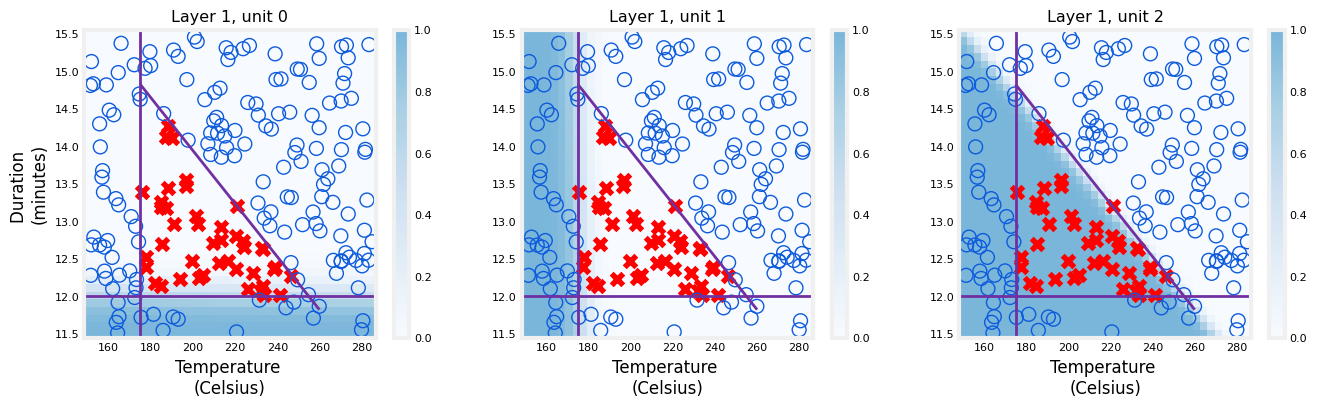

In [14]:
plt_layer(X,Y.reshape(-1,),W1,b1,norm_l)

### Visualizing last layer

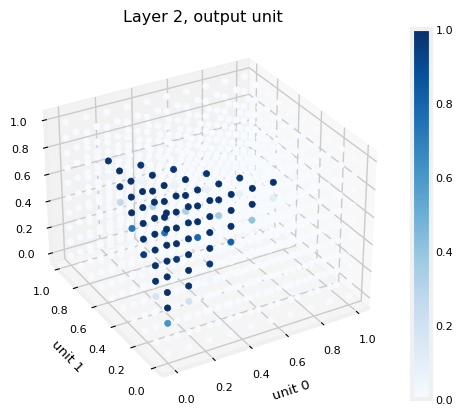

In [15]:
plt_output_unit(W2,b2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/ste

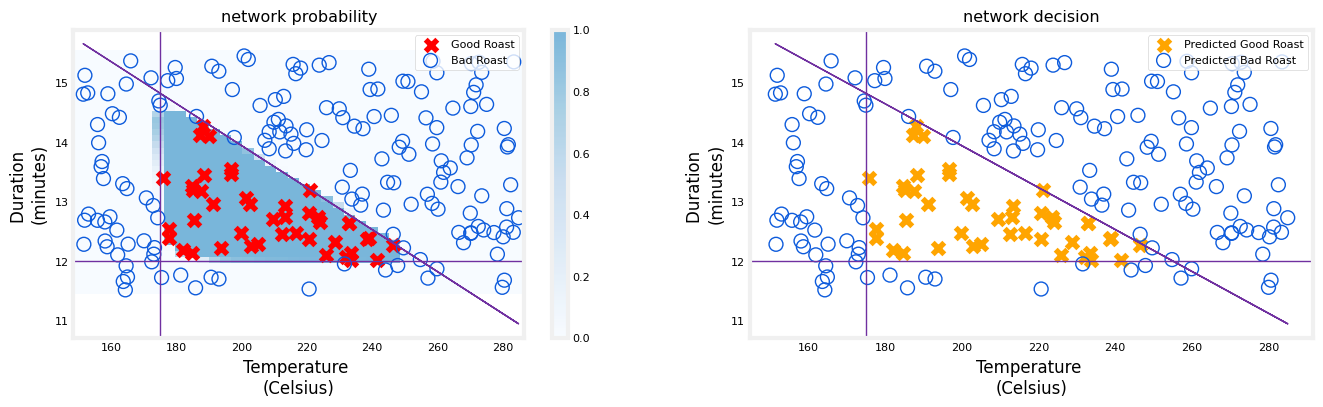

In [16]:
netf= lambda x : model.predict(norm_l(x))
plt_network(X,Y,netf)